--- Model Evaluation ---
R-squared: 0.67
Mean Squared Error (MSE): 24.29


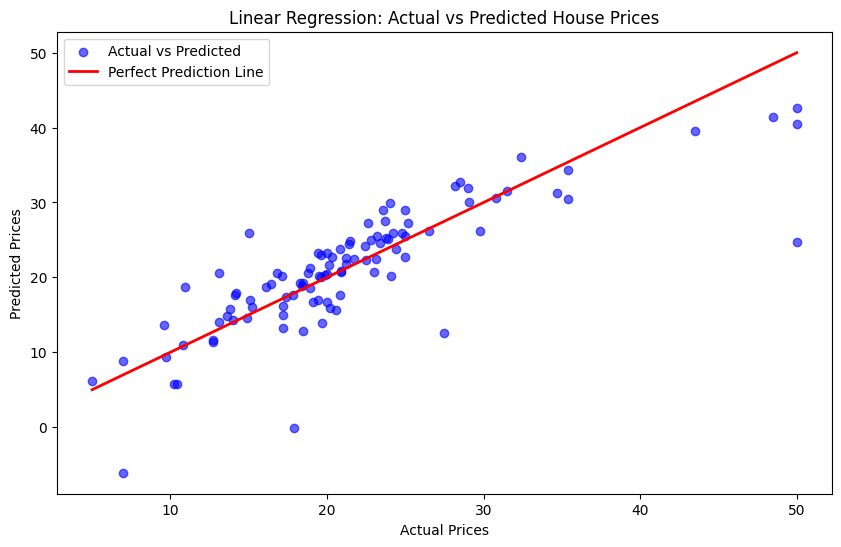

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
df = pd.read_csv('cleaned_house_data.csv')
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("--- Model Evaluation ---")
print(f"R-squared: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Linear Regression: Actual vs Predicted House Prices')
plt.legend()
plt.show()

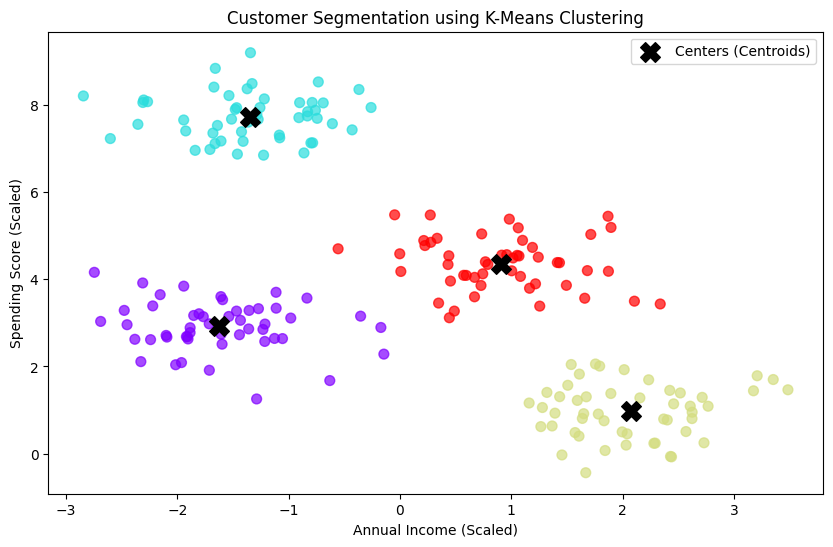

In [5]:
# 1. استدعاء المكتبات المطلوبة
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=200, centers=4, cluster_std=0.60, random_state=0)
df_customers = pd.DataFrame(X, columns=['Annual_Income', 'Spending_Score'])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_customers)

df_customers['Customer_Group'] = kmeans.labels_

plt.figure(figsize=(10,6))
plt.scatter(df_customers['Annual_Income'], df_customers['Spending_Score'], c=df_customers['Customer_Group'], cmap='rainbow', s=50, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='black', marker='X', s=200, label='Centers (Centroids)')

plt.title('Customer Segmentation using K-Means Clustering')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()